# Compliance Checker

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/phoebefu6/phoebe-the-builder/blob/main/document-intelligence/compliance-checker/demo.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/phoebefu6/phoebe-the-builder/main?labpath=document-intelligence/compliance-checker/demo.ipynb)

> Run a document against a policy ruleset before the auditor does.

Auditors keep finding the same violations because nobody checks policies before they ship.
This tool encodes policy **as code** - a ruleset of require/forbid patterns - and scores any
document against it, so violations surface at authoring time, not audit time.

**What this notebook covers**
1. Modeling policy as a ruleset (require vs forbid, severity)
2. A deterministic rules engine over a document
3. A weighted compliance score
4. Scoring a good vs a bad policy
5. A violations-by-severity chart
6. Where regex breaks and Claude takes over


## Step 1 - Policy as code

Each rule is data: an id, a pattern, a **mode** (`require` = must be present, `forbid` =
must be absent), and a severity. A compliance team owns this list - version it in git, and
"the policy" becomes reviewable and testable.

In [1]:
from __future__ import annotations

import re
from dataclasses import dataclass


@dataclass
class Rule:
    id: str
    description: str
    pattern: str
    mode: str = "require"      # require | forbid
    severity: str = "medium"   # low | medium | high | critical
    category: str = "general"

    def compiled(self):
        return re.compile(self.pattern, re.I)


DEFAULT_RULES = [
    Rule("GDPR-RETENTION", "Must state a data retention period",
         r"retention period|retain(ed)? for|delete.*after|data.*retained", "require", "high", "GDPR"),
    Rule("GDPR-CONSENT", "Must describe how consent is obtained",
         r"consent|opt[- ]?in|agree to", "require", "high", "GDPR"),
    Rule("GDPR-RIGHTS", "Must mention data subject rights (access/erasure)",
         r"right to (access|erasure|be forgotten)|data subject rights|request.*deletion",
         "require", "medium", "GDPR"),
    Rule("SEC-NO-PLAINTEXT-PW", "Must not store plaintext passwords",
         r"plain\s*text|clear\s*text|unencrypted password", "forbid", "critical", "Security"),
    Rule("SEC-ENCRYPTION", "Must state data is encrypted",
         r"encrypt(ed|ion)|aes-?256|tls", "require", "high", "Security"),
    Rule("SEC-NO-SHARED-CREDS", "Must not permit shared credentials",
         r"shared\s+(login|credentials|account)|share\s+your\s+password", "forbid", "high", "Security"),
    Rule("CONTACT-DPO", "Must give a data/privacy contact",
         r"data protection officer|dpo|privacy@|contact.*privacy", "require", "low", "Governance"),
]

print(len(DEFAULT_RULES), "rules loaded:",
      sum(r.mode == "require" for r in DEFAULT_RULES), "require /",
      sum(r.mode == "forbid" for r in DEFAULT_RULES), "forbid")


7 rules loaded: 5 require / 2 forbid


## Step 2 - The rules engine + score

Run every rule over the document. A `require` rule fails when its pattern is absent; a
`forbid` rule fails when its pattern is present. The score penalizes violations weighted by
severity, so one critical hit hurts more than three low ones.

In [2]:
@dataclass
class Finding:
    rule_id: str
    severity: str
    category: str
    status: str
    description: str = ""
    evidence: str = ""


def _snippet(text, m, pad=40):
    s, e = max(0, m.start() - pad), min(len(text), m.end() + pad)
    return ("..." if s else "") + text[s:e].strip() + ("..." if e < len(text) else "")


def check(text, rules=DEFAULT_RULES):
    findings = []
    for r in rules:
        m = r.compiled().search(text)
        present = m is not None
        violated = (not present) if r.mode == "require" else present
        findings.append(Finding(r.id, r.severity, r.category,
            "violation" if violated else "pass", r.description,
            _snippet(text, m) if m else ""))
    return findings


def score(findings):
    w = {"low": 1, "medium": 3, "high": 6, "critical": 10}
    total = sum(w[f.severity] for f in findings)
    pen = sum(w[f.severity] for f in findings if f.status == "violation")
    return round(100 * (1 - pen / total)) if total else 100


print("Engine ready.")


Engine ready.


## Step 3 - Score a good policy vs a bad one

Two documents: a clean privacy policy, and an internal note that would fail an audit.
Watch the score separate them.

In [3]:
GOOD = """Privacy & Security Policy
We encrypt all customer data at rest using AES-256 and in transit using TLS 1.3.
Passwords are hashed with bcrypt before storage and are never recoverable.
We collect data only after obtaining explicit consent (opt-in) at signup. Users may
exercise their right to access and right to erasure by emailing privacy@acme.com.
Personal data is retained for 24 months after account closure, then permanently deleted.
For privacy questions, contact our Data Protection Officer at dpo@acme.com."""

BAD = """Internal Systems Note
Users log in with a username and password. For convenience, team leads may use a shared
login for the ops dashboard. Passwords are stored in plaintext in the config table so we
can email them to users who forget. We keep customer records around indefinitely."""

for label, doc in [("GOOD", GOOD), ("BAD", BAD)]:
    f = check(doc)
    viol = [x for x in f if x.status == "violation"]
    print(f"{label}: score {score(f)}/100, {len(viol)} violation(s)")
    for v in viol:
        print(f"   [{v.severity:<8}] {v.rule_id}")
    print()


GOOD: score 100/100, 0 violation(s)

BAD: score 0/100, 7 violation(s)
   [high    ] GDPR-RETENTION
   [high    ] GDPR-CONSENT
   [medium  ] GDPR-RIGHTS
   [critical] SEC-NO-PLAINTEXT-PW
   [high    ] SEC-ENCRYPTION
   [high    ] SEC-NO-SHARED-CREDS
   [low     ] CONTACT-DPO



## Step 4 - Visualize violations by severity

The audit-ready view: how many violations at each severity, side by side. Empty bars on the
good doc, a red critical bar on the bad one.

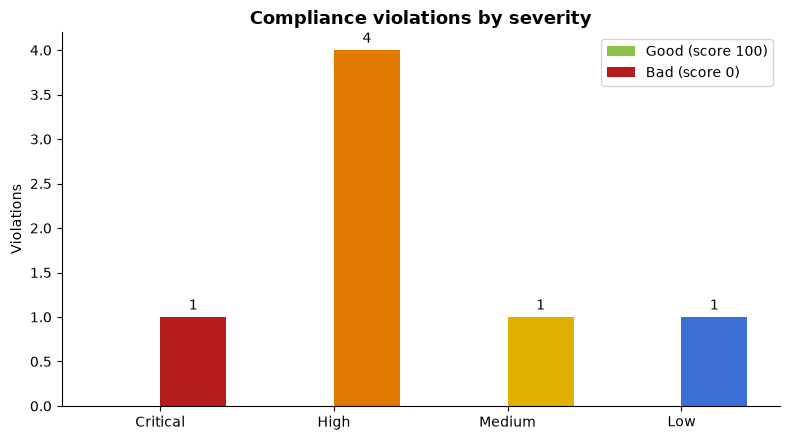

In [4]:
import matplotlib.pyplot as plt
import numpy as np

sevs = ["critical", "high", "medium", "low"]
colors = ["#b71c1c", "#e07b00", "#e0b000", "#3b6fd6"]


def sev_counts(doc):
    v = [f for f in check(doc) if f.status == "violation"]
    return [sum(1 for f in v if f.severity == s) for s in sevs]


good_c, bad_c = sev_counts(GOOD), sev_counts(BAD)
x = np.arange(len(sevs))
w = 0.38

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x - w/2, good_c, w, label=f"Good (score {score(check(GOOD))})", color="#8bc34a")
b2 = ax.bar(x + w/2, bad_c, w, label=f"Bad (score {score(check(BAD))})",
            color=[colors[i] for i in range(len(sevs))])
ax.set_xticks(x)
ax.set_xticklabels([s.capitalize() for s in sevs])
ax.set_ylabel("Violations")
ax.set_title("Compliance violations by severity", fontsize=13, weight="bold")
ax.bar_label(b2, padding=3)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("violations.png", dpi=120, bbox_inches="tight")
plt.show()


## Summary

| Document | Score | Worst violation |
|----------|-------|-----------------|
| Good policy | 100 | none |
| Bad policy | 0 | **critical** — plaintext passwords |

Policy-as-code turns "the auditor will find it" into "CI finds it first." Add a rule once,
and every future document is checked against it automatically.

## Where regex breaks - and Claude takes over

The engine is literal. It would flag "we **never** store plaintext passwords" as a
violation (the forbidden phrase is present, the negation is invisible to regex), and it
misses paraphrased compliance ("we purge records a year after you leave" satisfies
retention without the word "retention"). Claude judges by **meaning**, using the same
ruleset - so the human-authored policy stays the single source of truth.

In [5]:
# --- Upgrade to Claude (optional) ---
# import os, json, anthropic
#
# def llm_check(text, rules, api_key):
#     spec = [{"id": r.id, "description": r.description, "mode": r.mode} for r in rules]
#     client = anthropic.Anthropic(api_key=api_key)
#     resp = client.messages.create(model="claude-sonnet-4-5", max_tokens=1800,
#         messages=[{"role": "user", "content":
#             "Judge each rule pass/violation by MEANING. require=violation if unmet, "
#             "forbid=violation if present. JSON only.\n"
#             f"RULES:{json.dumps(spec)}\nDOC:\n{text}"}])
#     return json.loads(resp.content[0].text)["findings"]


In [6]:
# --- Try your own policy ---
# my_doc = """Paste a policy, contract, or SOP here..."""
# for f in check(my_doc):
#     if f.status == "violation":
#         print(f"[{f.severity}] {f.rule_id}: {f.description}")
# print("Score:", score(check(my_doc)))


---

Part of [**phoebe-the-builder**](https://github.com/phoebefu6/phoebe-the-builder) -
Day 39 of the 60-day FDE portfolio.

**Run the full app:**
```bash
pip install -r requirements.txt
streamlit run app.py
```
The Streamlit version shows the active ruleset, scores a document, and lists every finding
with evidence. Add an `ANTHROPIC_API_KEY` for meaning-based checking.